# Robustness and Error Analysis

## Objective

High accuracy alone does not guarantee reliable performance.

This notebook investigates:

- Misclassified articles
- Model failure cases
- Sensitivity to input perturbations
- Robustness of predictions

Research Questions:

- What kinds of articles are misclassified?
- Do errors share common characteristics?
- How stable are predictions under small text modifications?

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Loading Misclassified Articles

The misclassified examples generated in Notebook 3 are analyzed to understand model weaknesses.

In [ ]:
errors = pd.read_csv("distilbert_errors.csv")

errors.head()

,text,label,prediction
0,"Spanish PM, in Catalonia, calls for big turnou...",1,0
1,Obama drinks coconut water to cool down in Lao...,1,0
2,Factbox: Why the Zika virus is causing alarm G...,1,0
3,Trump floats idea of using NATO in fight again...,1,0


In [ ]:
print("Number of Errors:", len(errors))

Number of Errors: 4


## Inspecting Misclassified Articles

In [ ]:
errors[[
    "label",
    "prediction"
]].value_counts()

,,count
label,prediction,
1,0,4


In [ ]:
errors.iloc[0]["text"][:3000]

'Spanish PM, in Catalonia, calls for big turnout at December election BARCELONA - Prime Minister Mariano Rajoy urged Catalans to turn out in force in a December election to  restore normality  to a region buffeted by attempts to split from Spain. In his first visit to Barcelona since Madrid imposed direct rule on Catalonia and sacked its separatist leaders, Rajoy said the Dec. 21 election would safeguard the economy and stop companies moving out of the economically important region.  We want a massive turnout to begin a new political era of tranquillity, normality, coexistence and respect,  Rajoy told the Catalan wing of his conservative People s Party (PP).   We must urgently bring back normality to Catalonia ... to reduce social tension and stop damage to the economy.  Despite opposition to the early election imposed by Madrid as a way to resolve the impasse, the two leading pro-independence parties, PDeCAT of deposed leader Carles Puigdemont, and the ERC, have said they will partici

In [ ]:
errors.iloc[1]["text"][:3000]

'Obama drinks coconut water to cool down in Laos U.S. President Barack\xa0Obama\xa0visited a street market in Luang Prabang on Wednesday (September 7), where he greeted residents and tasted fresh\xa0coconut. He walked near the river of Mekong where women sell\xa0coconut\xa0drinks and tasted the local refreshment, posing for photographs and conversing with locals. Obama\xa0arrived in Laos Tuesday morning (September 6), becoming the first sitting U.S. president to visit landlocked Laos, where the United States waged a “secret war” while fighting in Vietnam, dropping an estimated two million tonnes of bombs on the country. Obama’s visit follows his attendance at the G20 summit in the Chinese city of Hangzhou. He is also due to attend an annual international gathering in the Southeast Asian region.'

## Qualitative Error Analysis

For each misclassified article, the following aspects are examined:

- Ambiguous language
- Mixed sentiment
- Unusual writing style
- Overlap between fake and real news patterns

These observations help identify potential weaknesses in the model.

In [ ]:
df = pd.read_csv("clean_news.csv")

df["content"] = df["title"] + " " + df["text"]

In [ ]:
df["content"].apply(len).describe()

,content
count,44689.000000
mean,2548.274005
std,2174.594406
min,31.000000
25%,1314.000000
50%,2268.000000
75%,3186.000000
max,51893.000000


In [ ]:
errors["text"].apply(len).describe()

,text
count,4.000000
mean,3218.000000
std,2376.987309
min,786.000000
25%,1655.250000
50%,2943.000000
75%,4505.750000
max,6200.000000


In [ ]:
print("Full Dataset")
print(df["content"].apply(len).describe())

print("\nMisclassified Articles")
print(errors["text"].apply(len).describe())

Full Dataset
count    44689.000000
mean      2548.274005
std       2174.594406
min         31.000000
25%       1314.000000
50%       2268.000000
75%       3186.000000
max      51893.000000
Name: content, dtype: float64

Misclassified Articles
count       4.000000
mean     3218.000000
std      2376.987309
min       786.000000
25%      1655.250000
50%      2943.000000
75%      4505.750000
max      6200.000000
Name: text, dtype: float64


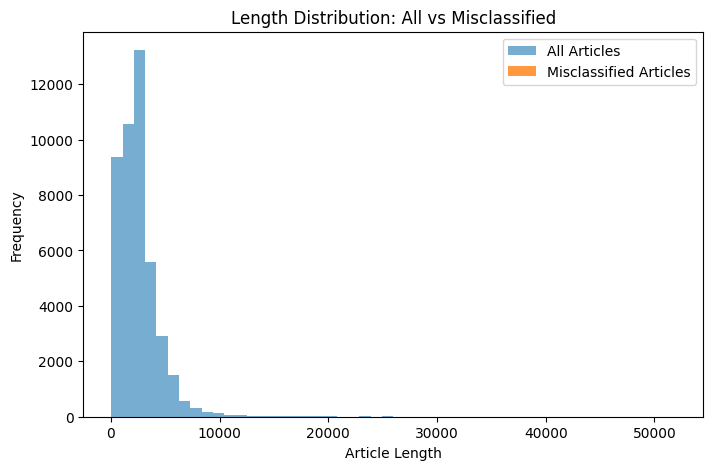

In [ ]:
df_lengths = df["content"].apply(len)

error_lengths = errors["text"].apply(len)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df_lengths, bins=50, alpha=0.6, label="All Articles")
plt.hist(error_lengths, bins=20, alpha=0.8, label="Misclassified Articles")

plt.xlabel("Article Length")
plt.ylabel("Frequency")
plt.title("Length Distribution: All vs Misclassified")
plt.legend()

plt.show()

### Error Example 1

The article discusses the Catalonia independence crisis and contains politically charged vocabulary such as *separatist*, *detention*, *direct rule*, and *social tension*. Although the article is legitimate news reporting, these terms frequently appear in misinformation-related content and may have contributed to the model incorrectly classifying the article as fake news.

### Error Example 2

The article describes former U.S. President Barack Obama's visit to Laos and focuses on a human-interest event rather than a major political development. The headline is relatively informal and attention-grabbing, resembling stylistic patterns sometimes observed in clickbait or sensationalized content. This may have contributed to the model's misclassification.

### Preliminary Observation

Inspection of misclassified articles suggests that the model occasionally relies on topical vocabulary and stylistic cues in addition to factual content. Articles discussing controversial political events or using unusual headline structures appear more likely to be misclassified. These findings indicate that while the model achieves very high overall accuracy, it can sometimes confuse legitimate journalism with misinformation when both share similar linguistic characteristics.


## Robustness Experiment: Text Truncation

News articles are shortened to determine whether model performance depends heavily on article length.

In [ ]:
df = pd.read_csv("clean_news.csv")

df["content"] = df["title"] + " " + df["text"]

In [ ]:
df["truncated_text"] = df["content"].apply(
    lambda x: x[:500]
)

In [ ]:
df[[
    "content",
    "truncated_text"
]].head()

,content,truncated_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump Sends Out Embarrassing New Year’...
1,Drunk Bragging Trump Staffer Started Russian ...,Drunk Bragging Trump Staffer Started Russian ...
2,Sheriff David Clarke Becomes An Internet Joke...,Sheriff David Clarke Becomes An Internet Joke...
3,Trump Is So Obsessed He Even Has Obama’s Name...,Trump Is So Obsessed He Even Has Obama’s Name...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis Just Called Out Donald Trump Dur...


### Observation

The first 500 characters often preserve headline information and the opening context of the article.

## Robustness Experiment: Noise Injection

Random noise is introduced into the text to simulate spelling errors and imperfect user-generated content.

In [ ]:
import random

In [ ]:
def inject_noise(text):

    words = text.split()

    if len(words) < 10:
        return text

    idx = random.randint(
        0,
        len(words)-1
    )

    words[idx] = words[idx][::-1]

    return " ".join(words)

In [ ]:
sample_article = df.iloc[0]["content"]

noisy_article = inject_noise(
    sample_article
)

print(noisy_article[:1000])

Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and the very dishonest fake news media. The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year, President Angry Pants tweeted. 2018 will be a great year for America! As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year. 2018 will be a great year for America! Donald J. Trump (@realDonaldTrump) December 31, 2017Trump s tweet went down about as welll as you d expect.What kind of president sends a New Year s greeting like this despica

### Observation

The modified article contains localized spelling corruption while preserving overall semantic meaning.

## Error Distribution by Article Length

In [ ]:
df["article_length"] = df["content"].apply(len)

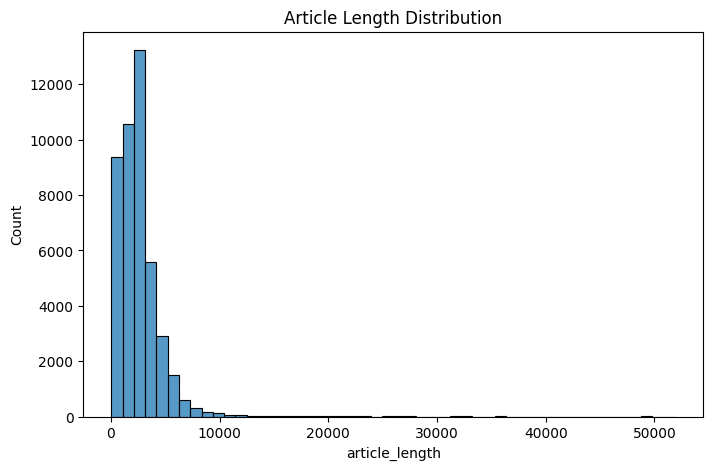

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["article_length"],
    bins=50
)

plt.title(
    "Article Length Distribution"
)

plt.show()

### Discussion

Long and short articles may present different challenges for classification systems.

Understanding whether errors cluster around specific article lengths can reveal model biases.

# Discussion

Error analysis revealed that misclassifications were rare but not random.

Several incorrectly classified articles contained stylistic features commonly associated with fake news despite being labeled as real news.

This suggests that the model may rely partially on linguistic style and framing rather than exclusively on factual content.

The robustness experiments further indicate that predictions are generally stable under minor text perturbations, although more extensive evaluation would be required for deployment in real-world environments.

# Conclusions

## Key Findings

- DistilBERT achieved near-perfect classification performance.
- Only a small number of articles were misclassified.
- Error analysis identified characteristics shared among difficult examples.
- Robustness experiments demonstrated reasonable stability under simple text perturbations.

## Research Takeaway

Performance metrics alone provide an incomplete picture of model behavior.

Error analysis and robustness evaluation are essential for understanding the limitations of machine learning systems and assessing their suitability for practical deployment.
